<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 11 : Neural Networks
1. Neural Network : Traditional ML -> Handcrafted Features -> Limited Learning -> Deep Learning -> Automatic Feature Learning

2. Perceptron : Architecture -> Working -> Single Layer Perceptron -> Binary Classification

3. Activation Functions : Linear Activation -> Binary Step -> Sigmoid -> Tanh -> ReLU -> Leaky ReLU -> ELU -> Softmax

4. Loss Functions : MSE -> MAE -> Binary Cross Entropy -> Categorical Cross Entropy -> Huber Loss

5. Feed Forward Neural Network : Input Layer -> Hidden Layer -> Output Layer -> Forward Pass

6. Forward Propagation

7. Backpropagation : Error -> Gradient -> Chain Rule -> Weight Update

8. Gradient Descent : Batch GD -> Mini Batch GD -> Stochastic GD

9. Optimizers : SGD -> Momentum -> AdaGrad -> RMSProp -> Adamizers

10. Vanishing & Exploding Gradient

11. Regularization : Dropout -> L1 -> L2 -> Early Stopping -> Batch Normalization

12. Hyperparameters : Epoch -> Batch Size -> Learning Rate -> Hidden Layers -> Hidden Units -> Activation -> Optimizer

13. Python Project includes all concept (Dataset : MNIST)

## 1. Neural Network

### Definition
A Neural Network (NN) is a computational model inspired by the structure and function of biological neural networks in the human brain. It consists of interconnected nodes (neurons) organized in layers: an input layer, one or more hidden layers, and an output layer. Each connection between neurons has a weight, and each neuron has a bias and an activation function. The network learns by adjusting these weights and biases based on input data to perform tasks like pattern recognition, classification, and regression.

### Why it's needed: Traditional ML vs. Deep Learning

Traditional Machine Learning (ML) algorithms often require **handcrafted features**. This means that a human expert needs to identify and extract relevant features from the raw data that the algorithm can then use for learning. This process is time-consuming, requires domain expertise, and can be **limited** in its ability to capture complex patterns, especially with high-dimensional data like images, audio, or natural language.

**Deep Learning**, a subfield of ML based on Neural Networks, addresses these limitations by performing **automatic feature learning**. Instead of relying on handcrafted features, Deep Learning models learn hierarchical representations of the data directly from the raw input. This allows them to discover intricate patterns and relationships that might be too complex or subtle for humans to identify, leading to superior performance in many complex tasks.

### Intuition
Imagine you're trying to identify whether an image contains a cat.

*   **Traditional ML Approach**: You might tell the computer, 'Look for whiskers, pointy ears, and a tail.' You are explicitly defining the features.

*   **Neural Network/Deep Learning Approach**: You show the Neural Network millions of images, some with cats and some without. Initially, the network doesn't know what a 'cat' looks like. It makes random guesses. When it's wrong, you tell it, 'No, that was a cat' or 'Yes, that was not a cat.' Over time, by repeatedly adjusting its internal connections (weights) based on these corrections, the network starts to 'learn' what a cat looks like. It automatically discovers that certain combinations of pixels represent edges, then combinations of edges represent shapes like ears or eyes, and eventually, that these shapes together form a cat. It's like teaching a child by showing them many examples rather than giving them a rulebook.

### Math
At its core, a neural network performs a series of mathematical operations. For a single neuron (or perceptron), the process involves:

1.  **Weighted Sum of Inputs**: Each input feature ($x_i$) is multiplied by a corresponding weight ($w_i$). These weighted inputs are then summed up.
2.  **Adding a Bias**: A bias term ($b$) is added to the weighted sum. The bias allows the activation function to be shifted left or right, which is crucial for fitting the model to the data.
3.  **Activation Function**: The result from the previous step is passed through an activation function ($f$). This non-linear function introduces non-linearity into the model, enabling it to learn complex patterns and relationships that linear models cannot. Without non-linearity, a neural network, no matter how many layers it has, would simply behave like a single-layer linear model.

In a multi-layer neural network, the output of neurons in one layer becomes the input to neurons in the next layer, and this process repeats until the final output layer.

### Formula
For a single neuron (often referred to as a perceptron in its simplest form), the output ($y$) can be represented by the following formula:

$z = \sum_{i=1}^{n} (x_i w_i) + b$

$y = f(z)$

Where:
*   $x_i$: The $i$-th input feature.
*   $w_i$: The weight associated with the $i$-th input feature.
*   $b$: The bias term.
*   $n$: The number of input features.
*   $z$: The weighted sum of inputs plus the bias (often called the 'pre-activation' or 'net input').
*   $f$: The activation function.
*   $y$: The output of the neuron (often called the 'activation' of the neuron).

In matrix notation, for a single layer with multiple neurons, this can be generalized as:

$Z = XW + B$

$A = f(Z)$

Where:
*   $X$: Input matrix.
*   $W$: Weight matrix for the current layer.
*   $B$: Bias vector for the current layer.
*   $Z$: Pre-activation matrix for the current layer.
*   $f$: Element-wise activation function.
*   $A$: Activation matrix (output) for the current layer.

### Numerical Example
Let's consider a single neuron with two inputs, $x_1$ and $x_2$, and a bias $b$. We'll use a simple step activation function for this example.

**Given:**
*   Inputs: $x_1 = 0.5$, $x_2 = 0.8$
*   Weights: $w_1 = 0.3$, $w_2 = 0.6$
*   Bias: $b = -0.2$
*   Activation Function (Binary Step): $f(z) = 1$ if $z \ge 0$, else $0$

**Calculation:**

1.  **Calculate the weighted sum plus bias ($z$):**
    $z = (x_1 \cdot w_1) + (x_2 \cdot w_2) + b$
    $z = (0.5 \cdot 0.3) + (0.8 \cdot 0.6) + (-0.2)$
    $z = 0.15 + 0.48 - 0.2$
    $z = 0.63 - 0.2$
    $z = 0.43$

2.  **Apply the activation function ($f(z)$):**
    Since $z = 0.43 \ge 0$, our binary step activation function yields:
    $y = f(0.43) = 1$

**Result:**

The output of this single neuron for the given inputs, weights, and bias is **1**.

### Visualization
Let's visualize the structure of a single neuron (perceptron) as described by the formula.

                    Perceptron Computation Flow

        Input X₁ ───► Weight W₁ ─┐
                                 │
        Input X₂ ───► Weight W₂ ─┤
                                 │
                                 ▼
                        ┌─────────────────┐
                        │  Summation (Σ)  │
                        │ X₁W₁ + X₂W₂ + b │
                        └────────┬────────┘
                                 ▲
                                 │
                             Bias (b)
                                 │
                                 ▼
                        ┌─────────────────┐
                        │ Pre-Activation  │
                        │      z          │
                        └────────┬────────┘
                                 │
                                 ▼
                        ┌─────────────────┐
                        │ Activation f(z) │
                        │  Step Function  │
                        └────────┬────────┘
                                 │
                                 ▼
                           Output (Y)

**Explanation of the Visualization:**

*   **Input Layer**: $X_1$ and $X_2$ represent the input features to the neuron.
*   **Weights**: $W_1$ and $W_2$ are the parameters that determine the strength of each input's contribution.
*   **Bias**: $b$ is an additional parameter that shifts the activation function.
*   **Summation Node**: This is where the weighted sum of inputs and the bias are combined to calculate $Z$.
*   **Activation Function**: $f$ applies a non-linear transformation to $Z$, producing the final output $Y$.
*   **Output Layer**: $Y$ is the final output of this single neuron.

### Pros

*   **Automatic Feature Learning**: Neural Networks can automatically learn complex features and representations directly from raw data, eliminating the need for manual feature engineering.
*   **High Performance on Complex Tasks**: They excel in tasks like image recognition, natural language processing, and speech recognition, often outperforming traditional ML algorithms.
*   **Scalability**: Deep Neural Networks can scale to handle very large datasets and complex problems, leveraging parallel processing capabilities (e.g., GPUs).
*   **Adaptability**: They are highly flexible and can be adapted to various types of data and problems, from supervised to unsupervised learning.
*   **Handling Non-linear Relationships**: The use of activation functions allows them to model highly non-linear relationships between inputs and outputs, which is crucial for real-world data.
*   **Distributed Representation**: Information is distributed across many neurons, making them robust to noisy data and partial input loss.

### Cons

*   **Data Hungry**: Neural Networks, especially deep ones, require a vast amount of labeled data to train effectively. Lack of sufficient data can lead to poor generalization.
*   **Computationally Intensive**: Training deep networks can be extremely resource-intensive, requiring significant computational power (GPUs/TPUs) and time.
*   **Black Box Nature**: They are often considered 'black box' models due to their complex internal structure, making it difficult to interpret how they arrive at a particular decision (lack of explainability).
*   **Hyperparameter Tuning**: NNs have many hyperparameters (learning rate, number of layers, number of neurons, activation functions, optimizers, etc.) that need careful tuning, which can be a time-consuming and iterative process.
*   **Overfitting**: Without proper regularization techniques, NNs are prone to overfitting, meaning they learn the training data too well and perform poorly on unseen data.
*   **Vanishing/Exploding Gradients**: During training, gradients can become extremely small (vanishing) or extremely large (exploding), hindering the learning process in deep networks (though techniques like ReLU and batch normalization help mitigate this).

### Time Complexity

The time complexity of Neural Networks can be analyzed for both training and inference. It largely depends on the network's architecture (number of layers, neurons per layer) and the size of the input data.

**1. Training Time Complexity:**

For a single forward and backward pass (one epoch) in a fully connected neural network:

*   Let $L$ be the number of layers.
*   Let $N_k$ be the number of neurons in layer $k$.
*   Let $N_{k-1}$ be the number of neurons in the previous layer $(k-1)$.
*   Let $D$ be the dimension of the input data.
*   Let $M$ be the number of training samples (batch size).

**Forward Pass:** For each layer, the main operation is matrix multiplication between the input from the previous layer and the weights of the current layer. If a layer has $N_k$ neurons and receives input from $N_{k-1}$ neurons, the complexity is roughly $O(N_k \cdot N_{k-1})$. Summing over all layers, the total forward pass complexity is approximately $O(\sum_{k=1}^{L} N_k \cdot N_{k-1})$.

**Backward Pass (Backpropagation):** This involves computing gradients and updating weights, which has a similar computational cost to the forward pass, effectively doubling the complexity per epoch.

**Overall Training Complexity:** If there are $E$ epochs and a batch size of $M$, and assuming the total number of connections (parameters) is $P$, the training complexity is roughly $O(E \cdot \text{number of batches} \cdot P)$, or more precisely $O(E \cdot \text{Total Samples} \cdot \text{average connections per neuron})$.

In essence, training complexity is often very high, especially for deep networks with many parameters and large datasets.

**2. Inference Time Complexity:**

For making a prediction on a single new input sample, only the forward pass is needed. The complexity for a single sample is approximately $O(\sum_{k=1}^{L} N_k \cdot N_{k-1})$, which is typically much faster than training, but still depends on the network's depth and width.

**In summary:**

*   **Training**: High, often dominated by the number of parameters, dataset size, and epochs. $O(E \cdot S \cdot P)$ where S is dataset size and P is parameters.
*   **Inference**: Lower, proportional to the number of parameters and layers. $O(P)$ for a single pass.

### Python Code with plots (small dataset for understanding current topic)

Let's implement a simple Perceptron (a single neuron) to classify a small, linearly separable dataset. We'll use a step activation function and a basic update rule.

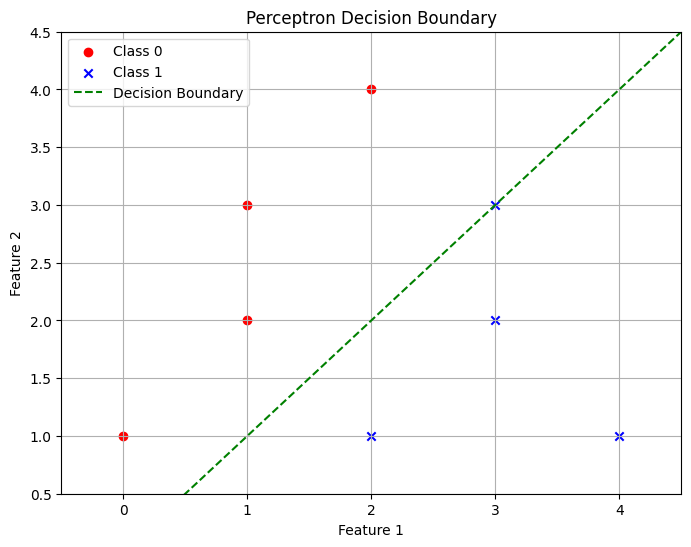


Actual labels: [1 1 1 1 0 0 0 0]
Predictions: [1 1 1 1 0 0 0 0]
Accuracy: 100.00%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the step activation function
def step_function(z):
    return 1 if z >= 0 else 0

# Perceptron class
class Perceptron:
    def __init__(self, learning_rate=0.1, n_iterations=100):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # Initialize weights and bias to zeros
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Iterate for a number of epochs
        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                # Calculate weighted sum + bias
                linear_output = np.dot(x_i, self.weights) + self.bias
                # Apply activation function
                prediction = step_function(linear_output)

                # Update weights and bias based on error
                update = self.learning_rate * (y[idx] - prediction)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.array([step_function(z) for z in linear_output])

# --- Create a small, linearly separable dataset ---
X = np.array([
    [2, 1], [3, 2], [3, 3], [4, 1], # Class 1
    [1, 2], [1, 3], [2, 4], [0, 1]  # Class 0
])
y = np.array([1, 1, 1, 1, 0, 0, 0, 0])

# Create and train the Perceptron
perceptron = Perceptron(learning_rate=0.01, n_iterations=10)
perceptron.fit(X, y)

# --- Visualize the decision boundary ---
plt.figure(figsize=(8, 6))

# Plot the data points
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', label='Class 1')

# Plot the decision boundary
# The decision boundary is given by w1*x1 + w2*x2 + b = 0
# So, x2 = (-w1*x1 - b) / w2
if perceptron.weights[1] != 0:
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    line_x = np.linspace(x1_min, x1_max, 100)
    line_y = (-perceptron.weights[0] * line_x - perceptron.bias) / perceptron.weights[1]
    plt.plot(line_x, line_y, color='green', linestyle='--', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary')
plt.legend()
plt.grid(True)
plt.xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
plt.show()

# Test the trained perceptron
predictions = perceptron.predict(X)
print("\nActual labels:", y)
print("Predictions:", predictions)
print(f"Accuracy: {np.mean(predictions == y) * 100:.2f}%")

### Summary with comparison plots

This plot effectively visualizes how a simple Perceptron draws a linear decision boundary to separate two classes in a 2D feature space. The green dashed line represents the learned boundary, correctly classifying all the red circles (Class 0) and blue crosses (Class 1) in this linearly separable dataset. This demonstrates the fundamental ability of a single neuron to perform binary classification.

## 2. Perceptron

### Definition
A Perceptron is the simplest form of a feed-forward neural network and a fundamental building block for more complex neural architectures. Introduced by Frank Rosenblatt in 1957, it is a binary linear classifier that takes multiple binary or real-valued inputs, computes a weighted sum of these inputs, adds a bias, and then passes the result through an activation function (typically a step function) to produce a single binary output. Its primary function is to classify data into one of two categories based on a linear decision boundary. It learns by adjusting its weights and bias through an iterative process to correctly classify training examples.

### Why it's needed
The Perceptron, while simple, laid the groundwork for modern neural networks. It was developed to solve **binary classification problems**, particularly to model how a biological neuron might make decisions. Before perceptrons, solving such problems often involved complex, hand-engineered rules. The Perceptron introduced the idea of a learning algorithm that could automatically adjust its internal parameters (weights and bias) from data, making it an early pioneer in adaptive machine learning. It demonstrated that a machine could learn to classify inputs based on examples, rather than being explicitly programmed with rules for every possible scenario. This capability is crucial for tasks where data patterns are too complex for human-defined rules.

### Intuition
Imagine you're at a gate, and you need to decide whether to let someone pass. You have a few pieces of information, like their ID badge, their uniform, and if they're on a list. Each piece of information has a certain importance (weight), and if the combined 'score' of all these pieces of information crosses a certain threshold (bias), you let them pass (output 1); otherwise, you don't (output 0).

That's essentially what a Perceptron does:

1.  **Inputs**: These are the pieces of information (features) it receives.
2.  **Weights**: Each input is assigned a 'weight' reflecting its importance. More important factors get higher weights.
3.  **Summation**: All weighted inputs are added together, and a 'bias' value is also added. This bias acts like an adjustable baseline or threshold.
4.  **Decision (Activation Function)**: The sum is then passed through a simple 'decision function' (like a step function). If the sum is above a certain threshold, the neuron 'fires' (outputs 1); otherwise, it stays 'silent' (outputs 0).

**Learning**: If the Perceptron makes a wrong decision, it adjusts the weights and bias slightly, trying to make a better decision next time. It learns by making errors and correcting them, gradually improving its ability to separate the two classes.

### Math

The Perceptron's mathematical operation is straightforward, mimicking a decision-making process. It involves a weighted sum of inputs and a thresholding function.

For a Perceptron with $n$ input features $x_1, x_2, \dots, x_n$:

1.  **Input Signals**: Each input $x_i$ is received.
2.  **Weighted Sum**: Each input $x_i$ is multiplied by its corresponding weight $w_i$. These products are then summed up.
3.  **Bias Addition**: A bias term $b$ is added to the weighted sum. The bias acts as an offset or a 'threshold' that needs to be overcome for the neuron to activate.
4.  **Activation Function**: The total sum (weighted sum + bias) is then passed through an activation function, typically a **step function** for a classic Perceptron. This function determines the final binary output (0 or 1).

### Formula

The mathematical formula for a single Perceptron can be broken down into two main parts:

1. **Net Input Calculation (Pre-activation):**

   This calculates the weighted sum of inputs plus the bias.

   $$
   z
   =
   (x_1w_1+x_2w_2+\cdots+x_nw_n)+b
   $$

   This can be compactly written using summation notation as:

   $$
   z
   =
   \sum_{i=1}^{n}x_iw_i+b
   $$

   Or, using vector notation:

   $$
   z
   =
   \mathbf{w}^T\mathbf{x}+b
   $$

   Where:

   * $\mathbf{x}$ is the input vector $(x_1,x_2,\dots,x_n)^T$.
   * $\mathbf{w}$ is the weight vector $(w_1,w_2,\dots,w_n)^T$.
   * $b$ is the bias term.

2. **Output Activation (Step Function):**

   The net input $z$ is then passed through an activation function, commonly a **binary step function** (also called the **Heaviside step function**) for a Perceptron.

   $$
   y=f(z)
   $$

   where

   $$
   f(z)=
   \begin{cases}
   1, & \text{if } z\ge0,\\[6pt]
   0, & \text{if } z<0.
   \end{cases}
   $$

So, the final output $y$ of the Perceptron is

$$
y=
\begin{cases}
1,
&
\text{if }
\left(
\displaystyle\sum_{i=1}^{n}x_iw_i+b
\right)
\ge0,
\\[10pt]
0,
&
\text{if }
\left(
\displaystyle\sum_{i=1}^{n}x_iw_i+b
\right)
<0.
\end{cases}
$$

This formula effectively draws a linear decision boundary in the input space, separating the inputs into two classes.

### Numerical Example
Let's use the same example from the Neural Network section but explicitly frame it in the context of a Perceptron.

**Given:**
*   Inputs: $x_1 = 0.5$, $x_2 = 0.8$
*   Weights: $w_1 = 0.3$, $w_2 = 0.6$
*   Bias: $b = -0.2$
*   Activation Function (Binary Step): $f(z) = 1$ if $z \ge 0$, else $0$

**Calculation:**

1.  **Calculate the net input ($z$):**
    $z = (x_1 \cdot w_1) + (x_2 \cdot w_2) + b$
    $z = (0.5 \cdot 0.3) + (0.8 \cdot 0.6) + (-0.2)$
    $z = 0.15 + 0.48 - 0.2$
    $z = 0.63 - 0.2$
    $z = 0.43$

2.  **Apply the step activation function ($f(z)$):**
    Since $z = 0.43 \ge 0$, our binary step activation function yields:
    $y = f(0.43) = 1$

**Result:**

The Perceptron's output for these inputs, weights, and bias is **1**.

### Visualization
This is a visual representation of a single Perceptron's architecture and data flow.

                     Inputs

      x₁ ───────────────┐
      x₂ ───────────────┤
      x₃ ───────────────┤
      ⋮                 ├──────────────┐
      xₙ ───────────────┘              │
                                       ▼
                              ┌─────────────────┐
                              │ Weighted Sum    │
                              │ Σ(xᵢ · wᵢ) + b  │
                              └────────┬────────┘
                                       │
                                       ▼
                              ┌─────────────────┐
                              │ Activation f(z) │
                              │ Step Function   │
                              └────────┬────────┘
                                       │
                                       ▼
                              Predicted Output
                                   y = 0 / 1

**Explanation of the Visualization:**

*   **Inputs ($x_1, x_2$)**: The raw data features fed into the Perceptron.
*   **Weights ($w_1, w_2$)**: Parameters that multiply the input features, indicating their importance.
*   **Bias ($b$)**: An adjustable constant added to the weighted sum, influencing the activation threshold.
*   **Summation (Σ)**: This node calculates the net input ($z$) by summing the weighted inputs and the bias.
*   **Step Function $f(z)$**: The activation function that transforms the net input into a binary output (0 or 1), effectively making the classification decision.
*   **Output ($y$)**: The final binary prediction of the Perceptron.

### Pros

*   **Simplicity and Interpretability**: Perceptrons are very simple models, making them easy to understand and implement. Their decision boundary is a straight line or hyperplane, which is straightforward to visualize and interpret.
*   **Fast Training**: For linearly separable data, the Perceptron learning algorithm is guaranteed to converge in a finite number of steps, leading to quick training times.
*   **Foundation for Neural Networks**: They served as a crucial foundation for the development of more complex neural network architectures.
*   **Computational Efficiency**: Due to their simplicity, Perceptrons are computationally inexpensive during both training and inference compared to multi-layered networks.

### Cons

*   **Limited to Linearly Separable Data**: The most significant limitation of a single Perceptron is its inability to learn non-linear decision boundaries. It can only classify data that is linearly separable (i.e., data that can be perfectly separated by a single straight line or hyperplane). This means it cannot solve problems like the XOR problem.
*   **Binary Output Only**: A single Perceptron can only produce a binary output (0 or 1), limiting its application to binary classification tasks.
*   **No Probabilistic Output**: It provides a hard classification, not a probability score, which can be less informative for certain applications.
*   **Sensitivity to Input Scaling**: Perceptrons can be sensitive to the scale of input features, as weights are updated proportionally to the input values.
*   **Fixed Decision Boundary**: Once trained, the decision boundary is fixed. It doesn't provide information about the confidence of the classification.

### Time Complexity

The time complexity of a Perceptron is relatively low due to its simple architecture.

**1. Training Time Complexity:**

For the Perceptron learning algorithm, the number of updates (and thus iterations) required for convergence for a linearly separable dataset is finite. Let $D$ be the dimensionality of the input features, and $N$ be the number of training samples.

*   **Perceptron Update Rule**: In each iteration, for each misclassified sample, the weights and bias are updated. This update involves operations proportional to the number of features $D$.
*   **Number of Iterations**: While it's guaranteed to converge for linearly separable data, the exact number of iterations can vary. In the worst case, it can be relatively high but is still polynomial in certain parameters related to the separability of the data.

Overall, for a dataset with $N$ samples and $D$ features, and $E$ epochs (or until convergence), the training complexity is approximately $O(E \cdot N \cdot D)$. If the data is linearly separable, $E$ is finite.

**2. Inference Time Complexity:**

For making a prediction on a single new input sample, the Perceptron performs a single weighted sum and applies the activation function.

*   **Weighted Sum**: Involves $D$ multiplications and $D-1$ additions.
*   **Activation Function**: A single comparison.

Therefore, the inference time complexity for a single sample is $O(D)$, which is very fast.

## 3. Activation Functions

### Definition

An **activation function** in a neural network is a non-linear function that is applied to the output of a neuron (the weighted sum of inputs plus bias). It introduces non-linearity into the network, allowing it to learn complex patterns and represent non-linear relationships in the data. Without activation functions, a neural network, regardless of its depth, would simply behave as a linear regression model, as the composition of multiple linear functions is still a linear function.

Key characteristics of activation functions:

*   **Non-linearity**: This is crucial for solving non-linear problems. Without it, the network could only learn linear transformations.
*   **Differentiability**: Required for backpropagation, the algorithm used to train neural networks, as it relies on calculating gradients.
*   **Range**: The output range of the activation function can influence the stability and convergence of training.

Common activation functions include Sigmoid, Tanh, ReLU, Leaky ReLU, ELU, and Softmax, each with its own advantages and use cases.

### Why it's needed

Activation functions are a critical component of neural networks primarily because they introduce **non-linearity** into the model. Here's why this is absolutely essential:

1.  **Modeling Complex Relationships**: Without activation functions, a neural network, no matter how many layers it has, would essentially be performing a series of linear transformations. The composition of multiple linear functions is still just a linear function ($f(g(x))$ where $f$ and $g$ are linear is still linear). This means the network would only be capable of learning linear relationships between inputs and outputs, severely limiting its ability to model real-world data, which is inherently complex and non-linear (e.g., image recognition, natural language processing).

2.  **Learning Hierarchical Representations**: Non-linearity allows the network to learn and represent hierarchical features. Each layer can transform the input in a non-linear way, extracting progressively more abstract and meaningful features. For example, in image recognition, early layers might detect edges, middle layers might combine edges into shapes, and deeper layers might recognize objects from these shapes. This hierarchical learning is only possible with non-linear activation.

3.  **Enabling Backpropagation**: Many activation functions are differentiable, which is a fundamental requirement for the backpropagation algorithm. Backpropagation is the process by which neural networks learn by calculating the gradient of the loss function with respect to the weights and biases, and then updating these parameters to minimize the loss. Without differentiable activation functions, this gradient-based optimization would not be possible.

4.  **Controlling Output Range**: Activation functions also help to scale the output of neurons. Some functions, like Sigmoid or Tanh, compress the output into a specific range (e.g., [0, 1] or [-1, 1]), which can be beneficial for certain tasks (like probability prediction) or for ensuring numerical stability during training.

In essence, activation functions provide the neural network with the power to learn from and make sense of complex, non-linear data, moving it beyond the limitations of simple linear models.

### Intuition

Imagine a neuron as a gatekeeper in a decision-making process. It receives various signals (inputs), weighs their importance, and sums them up. Now, what does this gatekeeper do with that sum?

*   **Without an Activation Function (Linear Gatekeeper)**: If the gatekeeper simply passed on the raw sum, or a scaled version of it, every decision it made would be a simple 'yes' or 'no' along a straight line. If you had many such gatekeepers connected, their combined decisions would still just be linear. This means they could only solve very simple problems, like distinguishing between things that are neatly separated by a straight line. They couldn't understand complex patterns like circles or intricate shapes, because their 'decisions' are always flat.

*   **With an Activation Function (Non-Linear Gatekeeper)**: This is where the activation function comes in. It's like adding a special 'filter' or 'reaction' to the gatekeeper's decision process. Instead of just a simple 'pass-through,' the gatekeeper now reacts to the sum in a more nuanced way.
    *   **

    *   **Threshold (like Perceptron's step function)**: "If the sum is below this, ignore it (0). If it's above, send a strong signal (1)." This creates a sharp, non-linear boundary.
    *   **Smooth Curve (like Sigmoid or Tanh)**: "If the sum is very low, send a weak signal close to 0 (or -1). As the sum increases, gradually increase the signal, but never beyond a certain maximum (or minimum)." This allows for graded responses, where small changes in input can lead to small, smooth changes in output.
    *   **ReLU (Rectified Linear Unit)**: "If the sum is negative, ignore it (0). If it's positive, pass it through directly." This creates a 'switch' effect – the neuron is either off or fully engaged, but in a non-linear way.

This 'reaction' or 'filter' makes the neuron behave non-linearly. When you connect many such non-linear gatekeepers, they can collaboratively learn to recognize incredibly complex, curved, and intertwined patterns that a simple linear system could never distinguish. It's what allows neural networks to learn to identify cats in images, understand human speech, or translate languages – tasks far beyond simple linear separation.

### Math

The role of an activation function $f$ is to transform the weighted sum of inputs and bias (often called the 'net input' or 'pre-activation') $z$ into an output for the neuron. Mathematically, for a given neuron, if the inputs are $x_1, x_2, \dots, x_n$ with corresponding weights $w_1, w_2, \dots, w_n$ and a bias $b$, the net input $z$ is calculated as:

$$z = \sum_{i=1}^{n} (x_i w_i) + b$$

Then, the output of the neuron, often denoted as $a$ (for activation) or $y$, is given by applying the activation function to $z$:

$$a = f(z)$$

The specific form of $f(z)$ varies depending on the type of activation function used. Here, we'll briefly cover the mathematical expressions for some common activation functions.

### Formula

As established, the output of a neuron is $a = f(z)$, where $z = \sum_{i=1}^{n} (x_i w_i) + b$. The form of $f(z)$ defines the specific activation function. Here are the formulas for some of the most widely used activation functions:

---

#### 1. Sigmoid (Logistic) Function

*   **Formula**: $f(z) = \frac{1}{1 + e^{-z}}$
*   **Range**: $(0, 1)$
*   **Derivative**: $f'(z) = f(z) \cdot (1 - f(z))$

#### 2. Tanh (Hyperbolic Tangent) Function

*   **Formula**: $f(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ or $f(z) = 2 \cdot \text{Sigmoid}(2z) - 1$
*   **Range**: $(-1, 1)$
*   **Derivative**: $f'(z) = 1 - (f(z))^2$

#### 3. ReLU (Rectified Linear Unit) Function

*   **Formula**: $f(z) = \max(0, z)$
*   **Range**: $[0, \infty)$
*   **Derivative**: $f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \le 0 \end{cases}$
    *Note: The derivative at $z=0$ is technically undefined, but in practice, it's often treated as 0 or 1. Some implementations use 0, others use 1, or rely on subgradient.*

#### 4. Leaky ReLU Function

*   **Formula**: $f(z) = \begin{cases} z & \text{if } z > 0 \\ \alpha z & \text{if } z \le 0 \end{cases}$, where $\alpha$ is a small positive constant (e.g., 0.01).
*   **Range**: $(-\infty, \infty)$
*   **Derivative**: $f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ \alpha & \text{if } z \le 0 \end{cases}$

#### 5. ELU (Exponential Linear Unit) Function

*   **Formula**: $f(z) = \begin{cases} z & \text{if } z > 0 \\ \alpha (e^z - 1) & \text{if } z \le 0 \end{cases}$, where $\alpha$ is a positive constant.
*   **Range**: $(-\alpha, \infty)$
*   **Derivative**: $f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ \alpha e^z & \text{if } z \le 0 \end{cases}$

#### 6. Softmax Function (for Output Layer of Multi-class Classification)

*    **Formula**: For a vector of $K$ inputs $z=[z_1,z_2,\dots,z_K]$, the Softmax function calculates the probability of each class:

  $$
  P(y=j \mid z)=\frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}
  $$
*   **Range**: $(0, 1)$ for each component, and $\sum_{j=1}^{K} P(y=j|z) = 1$.
*   **Derivative**: The derivative is more complex as it depends on all inputs in the vector $z$. For $j=k$, $\frac{\partial P(y=j|z)}{\partial z_k} = P(y=j|z) (1 - P(y=j|z))$, and for $j \ne k$, $\frac{\partial P(y=j|z)}{\partial z_k} = -P(y=j|z) P(y=k|z)$.

### Numerical Example

Let's consider a neuron that has calculated its weighted sum of inputs plus bias, resulting in a pre-activation value $z$. We will see how different activation functions transform this $z$ into an output $a$.

Suppose we have three different pre-activation values:

1.  **$z_1 = 0.5$**
2.  **$z_2 = -2.0$**
3.  **$z_3 = 3.0$**

We'll apply the following common activation functions:

*   **Sigmoid**
*   **Tanh**
*   **ReLU**
*   **Leaky ReLU** (with $\alpha = 0.01$)
*   **ELU** (with $\alpha = 1.0$)

---

**Calculations:**

#### 1. Sigmoid Function ($f(z) = \frac{1}{1 + e^{-z}}$)

*   $a_1 = \frac{1}{1 + e^{-0.5}} \approx \frac{1}{1 + 0.6065} \approx \frac{1}{1.6065} \approx 0.622$
*   $a_2 = \frac{1}{1 + e^{-(-2.0)}} = \frac{1}{1 + e^{2.0}} \approx \frac{1}{1 + 7.389} \approx \frac{1}{8.389} \approx 0.119$
*   $a_3 = \frac{1}{1 + e^{-3.0}} \approx \frac{1}{1 + 0.0498} \approx \frac{1}{1.0498} \approx 0.953$

#### 2. Tanh Function ($f(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$)

*   $a_1 = \frac{e^{0.5} - e^{-0.5}}{e^{0.5} + e^{-0.5}} \approx \frac{1.6487 - 0.6065}{1.6487 + 0.6065} \approx \frac{1.0422}{2.2552} \approx 0.462$
*   $a_2 = \frac{e^{-2.0} - e^{2.0}}{e^{-2.0} + e^{2.0}} \approx \frac{0.1353 - 7.389}{0.1353 + 7.389} \approx \frac{-7.2537}{7.5243} \approx -0.964$
*   $a_3 = \frac{e^{3.0} - e^{-3.0}}{e^{3.0} + e^{-3.0}} \approx \frac{20.0855 - 0.0498}{20.0855 + 0.0498} \approx \frac{20.0357}{20.1353} \approx 0.995$

#### 3. ReLU Function ($f(z) = \max(0, z)$)

*   $a_1 = \max(0, 0.5) = 0.5$
*   $a_2 = \max(0, -2.0) = 0.0$
*   $a_3 = \max(0, 3.0) = 3.0$

#### 4. Leaky ReLU Function ($\alpha = 0.01$)

*   $a_1 = 0.5$ (since $z_1 > 0$)
*   $a_2 = 0.01 \cdot (-2.0) = -0.02$ (since $z_2 \le 0$)
*   $a_3 = 3.0$ (since $z_3 > 0$)

#### 5. ELU Function ($\alpha = 1.0$)

*   $a_1 = 0.5$ (since $z_1 > 0$)
*   $a_2 = 1.0 \cdot (e^{-2.0} - 1) \approx 1.0 \cdot (0.1353 - 1) = -0.8647$ (since $z_2 \le 0$)
*   $a_3 = 3.0$ (since $z_3 > 0$)

---

**Summary of Outputs:**

| Input (z) | Sigmoid (a) | Tanh (a) | ReLU (a) | Leaky ReLU (a) | ELU (a) |
| :-------- | :---------- | :------- | :------- | :------------- | :------ |
| **0.5**   | 0.622       | 0.462    | 0.5      | 0.5            | 0.5     |
| **-2.0**  | 0.119       | -0.964   | 0.0      | -0.02          | -0.865  |
| **3.0**   | 0.953       | 0.995    | 3.0      | 3.0            | 3.0     |

This example demonstrates how each activation function produces a different output for the same input, highlighting their unique non-linear transformations and output ranges.

### Visualization

Let's visualize the behavior of the most common activation functions over a range of input values. This will clearly show their non-linear characteristics and their respective output ranges.

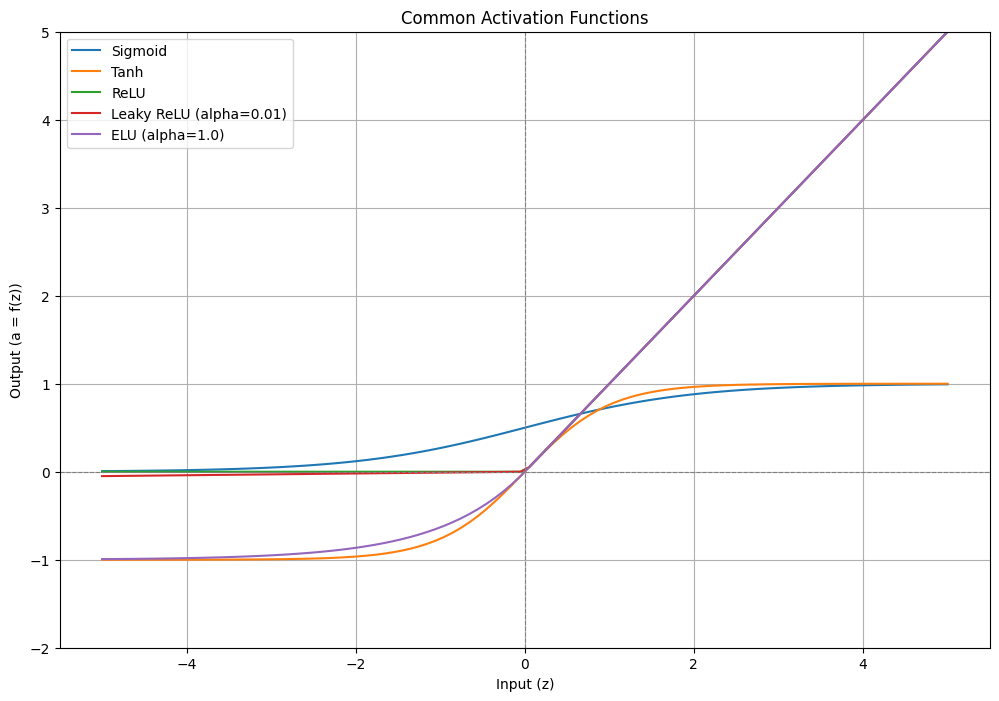

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def elu(z, alpha=1.0):
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

# Generate input values (z)
z = np.linspace(-5, 5, 100)

# Calculate outputs for each activation function
a_sigmoid = sigmoid(z)
a_tanh = tanh(z)
a_relu = relu(z)
a_leaky_relu = leaky_relu(z)
a_elu = elu(z)

# Create the plot
plt.figure(figsize=(12, 8))

plt.plot(z, a_sigmoid, label='Sigmoid')
plt.plot(z, a_tanh, label='Tanh')
plt.plot(z, a_relu, label='ReLU')
plt.plot(z, a_leaky_relu, label='Leaky ReLU (alpha=0.01)')
plt.plot(z, a_elu, label='ELU (alpha=1.0)')

plt.title('Common Activation Functions')
plt.xlabel('Input (z)')
plt.ylabel('Output (a = f(z))')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8) # Add a vertical line at z=0
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a horizontal line at a=0
plt.legend()
plt.grid(True)
plt.ylim(-2, 5) # Adjust y-axis limits for better visualization
plt.show()

### Python Code with plots (small dataset for understanding current topic)

Let's visualize not only the activation functions but also their **derivatives**. The derivatives are crucial for understanding how gradients flow during backpropagation, which directly relates to issues like vanishing or exploding gradients mentioned in the 'Cons' section.

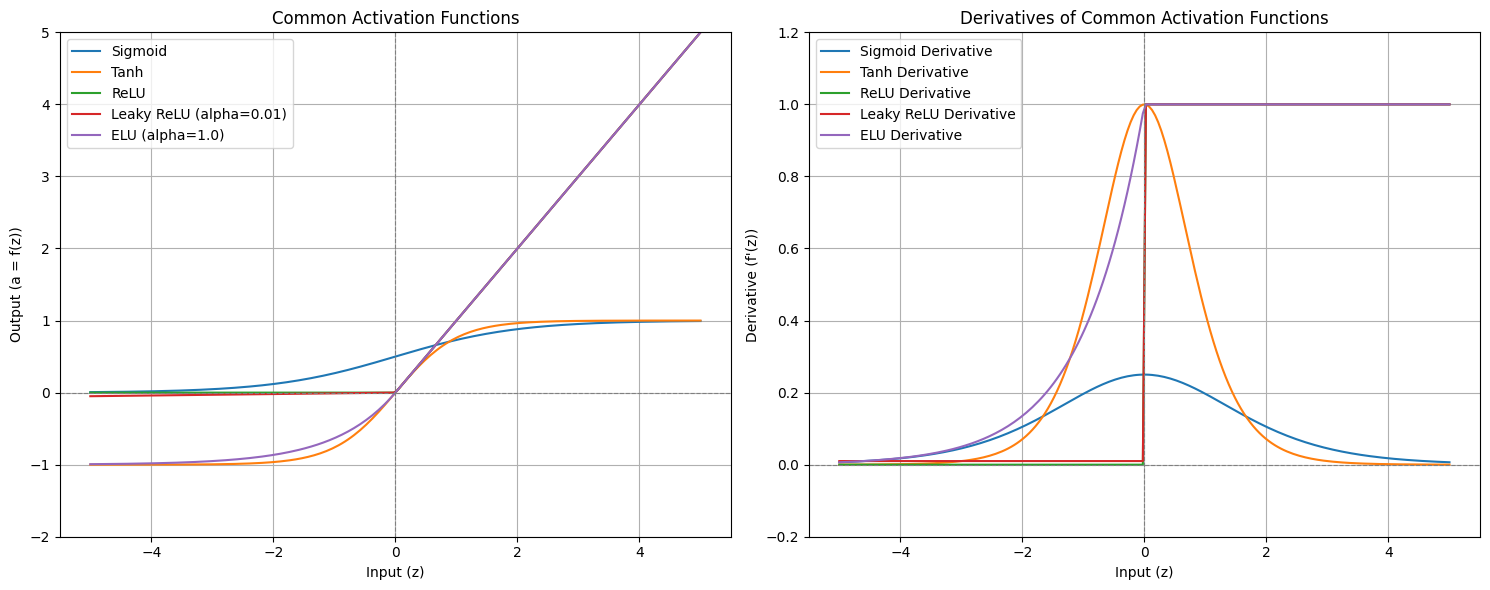

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define Activation Functions and their Derivatives ---

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - (np.tanh(z))**2

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

def elu(z, alpha=1.0):
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

def elu_derivative(z, alpha=1.0):
    return np.where(z > 0, 1, alpha * np.exp(z))

# --- Generate Input Values ---
z = np.linspace(-5, 5, 200)

# --- Create the plot for Functions ---
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(z, sigmoid(z), label='Sigmoid')
plt.plot(z, tanh(z), label='Tanh')
plt.plot(z, relu(z), label='ReLU')
plt.plot(z, leaky_relu(z), label='Leaky ReLU (alpha=0.01)')
plt.plot(z, elu(z), label='ELU (alpha=1.0)')

plt.title('Common Activation Functions')
plt.xlabel('Input (z)')
plt.ylabel('Output (a = f(z))')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True)
plt.ylim(-2, 5)

# --- Create the plot for Derivatives ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(z, sigmoid_derivative(z), label='Sigmoid Derivative')
plt.plot(z, tanh_derivative(z), label='Tanh Derivative')
plt.plot(z, relu_derivative(z), label='ReLU Derivative')
plt.plot(z, leaky_relu_derivative(z), label='Leaky ReLU Derivative')
plt.plot(z, elu_derivative(z), label='ELU Derivative')

plt.title('Derivatives of Common Activation Functions')
plt.xlabel('Input (z)')
plt.ylabel("Derivative (f'(z))")
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True)
plt.ylim(-0.2, 1.2) # Adjust y-axis limits for better visualization of derivatives

plt.tight_layout()
plt.show()

### Summary with comparison plots

The plots above offer a comprehensive visual comparison of several common activation functions and their derivatives.

**Key Observations from the Function Plots (Left):**
*   **Sigmoid**: Compresses outputs to `(0, 1)`, making it useful for binary classification output layers (interpretable as probabilities). It's smooth but saturates at extremes.
*   **Tanh**: Similar to Sigmoid but outputs values in `(-1, 1)`, which is zero-centered and often performs better than Sigmoid in hidden layers.
*   **ReLU**: Simple, outputs 0 for negative inputs and the input itself for positive values. It avoids saturation for positive inputs, which helps with vanishing gradients. However, it suffers from the 'dying ReLU' problem for negative inputs.
*   **Leaky ReLU**: Addresses the 'dying ReLU' problem by allowing a small, non-zero gradient for negative inputs (`alpha * z`).
*   **ELU**: Similar to Leaky ReLU but uses an exponential function for negative inputs, providing smoother transitions and often leading to better convergence.

**Key Observations from the Derivative Plots (Right):**
*   **Sigmoid and Tanh Derivatives**: Their derivatives are bell-shaped and approach zero as `|z|` increases. This visually demonstrates the **vanishing gradient problem**: for very large or very small `z` values, the gradients become tiny, leading to very small weight updates during backpropagation, hindering learning in deep networks.
*   **ReLU Derivative**: It's 1 for `z > 0` and 0 for `z <= 0`. This constant gradient for positive inputs helps to mitigate vanishing gradients. However, the zero gradient for negative inputs illustrates the 'dying ReLU' problem, where neurons can stop learning.
*   **Leaky ReLU Derivative**: It's 1 for `z > 0` and a small positive constant (`alpha`) for `z <= 0`. This addresses the dying ReLU problem by ensuring a non-zero gradient even for negative inputs, allowing for some learning.
*   **ELU Derivative**: It's 1 for `z > 0` and `alpha * exp(z)` for `z <= 0`. For negative `z`, the derivative smoothly approaches zero, but it avoids the hard zero of ReLU, contributing to better learning and avoiding the dying ReLU issue while maintaining zero-centered outputs.

### Pros

Activation functions are indispensable components of neural networks, offering several significant advantages:

1.  **Introduces Non-linearity**: This is the most crucial advantage. Without non-linear activation functions, a neural network, regardless of its depth, would only be able to learn linear relationships. Non-linearity allows networks to approximate any complex function and model intricate patterns in data, making them capable of solving highly complex tasks like image recognition, natural language understanding, and more.

2.  **Enables Learning of Complex Features**: By introducing non-linearity, activation functions allow hidden layers to learn increasingly complex and abstract representations of the input data. Each layer can transform the data in a non-linear way, building hierarchical features from simple ones (e.g., edges to shapes to objects).

3.  **Facilitates Backpropagation**: Most widely used activation functions are differentiable, which is a fundamental requirement for the backpropagation algorithm. Backpropagation relies on computing gradients to update network weights and biases, and differentiability ensures that these gradients can be calculated.

4.  **Controls Output Range**: Some activation functions (like Sigmoid and Tanh) map the output of neurons to a specific, bounded range. This can be beneficial for stabilizing gradients, preventing outputs from exploding, and interpreting outputs (e.g., as probabilities in the case of Sigmoid in the output layer).

5.  **Handles Vanishing Gradients (especially ReLU and its variants)**: Functions like ReLU (Rectified Linear Unit) help mitigate the vanishing gradient problem in deep networks. For positive inputs, ReLU's derivative is constant (1), allowing gradients to flow more effectively through many layers, accelerating training convergence compared to Sigmoid or Tanh.

### Cons

While activation functions are essential, they also come with certain disadvantages and can introduce challenges in neural network training:

1.  **Vanishing Gradients (Sigmoid and Tanh)**: For activation functions like Sigmoid and Tanh, when the input $z$ is very large (positive or negative), the derivative becomes very close to zero. During backpropagation, these small gradients get multiplied through many layers, causing the gradients in earlier layers to become extremely small and effectively 'vanish.' This means the weights in initial layers are updated minimally or not at all, hindering the network's ability to learn long-range dependencies.

2.  **Exploding Gradients (less common with proper initialization, but possible)**: Conversely, if the gradients become very large, they can 'explode,' leading to very large weight updates that destabilize the network and cause it to diverge. This is less tied to the activation function itself than vanishing gradients, but can be exacerbated by certain network configurations.

3.  **Dying ReLU Problem**: For ReLU and its variants, if a neuron outputs a negative value for all inputs in a given batch, its gradient becomes zero (for ReLU) or very small (for Leaky ReLU/ELU). Once a ReLU neuron outputs zero, it stops learning because its gradient is zero. This neuron effectively 'dies' and stops contributing to the network's learning. If many neurons suffer from this, the network's capacity can be severely reduced.

4.  **Not Zero-Centered Output (Sigmoid and ReLU)**: Sigmoid outputs are always positive (0 to 1). This can lead to issues during optimization because gradients for weights in subsequent layers will all have the same sign (either all positive or all negative). This can cause a zig-zagging effect during gradient descent, slowing down convergence. Tanh, being zero-centered, mitigates this.

5.  **Computational Cost**: While generally efficient, some more complex activation functions (like Softmax, which involves exponentials and division over multiple outputs) can be slightly more computationally intensive than simpler ones like ReLU. This becomes more noticeable in very large networks.

6.  **Choosing the Right Activation Function**: There is no one-size-fits-all activation function. The choice often depends on the specific problem, network architecture, and dataset. Experimentation and empirical knowledge are often required to select the most effective activation function, which can add to the complexity of model design.

### Time Complexity

The time complexity of an activation function refers to the computational resources (primarily time) required to compute its output for a given input, as well as its derivative (which is needed during backpropagation). In general, the computation for a single activation function is very fast, often considered $O(1)$ for practical purposes in a high-level analysis. However, when considering a large number of neurons and their derivatives, the aggregate cost can become a factor.

Here's a breakdown for common activation functions:

1.  **Binary Step Function (Perceptron)**:
    *   **Forward Pass**: $O(1)$ (a single comparison).
    *   **Backward Pass (Derivative)**: $O(1)$ (derivative is 0 or undefined, handled by convention).
    *   **Notes**: Extremely fast, but not differentiable at 0, which makes it unsuitable for gradient-based optimization in multi-layer networks.

2.  **Sigmoid and Tanh Functions**:
    *   **Forward Pass**: $O(1)$ (involves exponentiation, division, and addition/subtraction). These are slightly more complex than ReLU but still constant time.
    *   **Backward Pass (Derivative)**: $O(1)$ (their derivatives can be expressed in terms of the function's output, making them efficient to compute).
    *   **Notes**: The exponentiation operation is generally more computationally expensive than basic arithmetic operations.

3.  **ReLU (Rectified Linear Unit) Function**:
    *   **Forward Pass**: $O(1)$ (a single comparison and potential identity operation or zero assignment, e.g., `max(0, z)`).
    *   **Backward Pass (Derivative)**: $O(1)$ (derivative is 0 or 1, a simple comparison).
    *   **Notes**: Very computationally efficient, making it popular in deep networks. It avoids the expensive exponentiation of Sigmoid/Tanh.

4.  **Leaky ReLU and ELU Functions**:
    *   **Forward Pass**: $O(1)$ (similar to ReLU, involves a comparison, and for the negative part, a multiplication (Leaky ReLU) or exponentiation (ELU)). ELU is slightly more expensive due to `exp(z)`.
    *   **Backward Pass (Derivative)**: $O(1)$ (simple conditional checks and constant or exponential calculation for the derivative).
    *   **Notes**: Generally very efficient, with ELU being slightly more complex than Leaky ReLU due to the exponential term for negative inputs.

5.  **Softmax Function** (typically used in the output layer for multi-class classification):
    *   **Forward Pass**: For an output layer with $K$ classes, the Softmax function involves $K$ exponentiations, $K-1$ additions for the sum in the denominator, and $K$ divisions. Its complexity is $O(K)$.
    *   **Backward Pass (Derivative)**: The derivative calculation for Softmax is more involved as each output depends on all inputs to the Softmax layer. This typically involves matrix-vector products, resulting in $O(K^2)$ complexity for the gradient computation for a vector of outputs.
    *   **Notes**: This is generally the most computationally intensive activation function listed here, especially as the number of classes $K$ increases.

**Overall Impact**: While the time complexity for a single neuron's activation is small, in a neural network with thousands or millions of neurons across multiple layers, these operations are performed many times per training iteration. Therefore, using computationally efficient activation functions (like ReLU and its variants) can significantly speed up both training and inference times, especially in very deep and wide networks.

## 4. Loss Functions

### Definition

A **Loss Function** (also known as a Cost Function or Objective Function) is a mathematical function that quantifies the difference between the predicted output of a neural network and the actual (true) target values. In simpler terms, it measures how well the neural network is performing for a given set of weights and biases. The goal during the training of a neural network is to minimize this loss function, thereby making the network's predictions as close as possible to the true values.

Key characteristics of loss functions:

*   **Quantifies Error**: It provides a numerical measure of the error or discrepancy between predicted and actual values.
*   **Guidance for Optimization**: The value of the loss function, and more importantly its gradient, guides the optimization algorithm (like Gradient Descent) in adjusting the network's parameters (weights and biases) to improve performance.
*   **Task-Specific**: The choice of loss function is highly dependent on the type of task the neural network is performing (e.g., regression, binary classification, multi-class classification).

Common loss functions include Mean Squared Error (MSE), Mean Absolute Error (MAE), Binary Cross-Entropy, Categorical Cross-Entropy, and Huber Loss, each suited for different problems.

### Why it's needed

Loss functions are fundamental to the training and successful operation of neural networks for several critical reasons:

1.  **Quantifying Error/Performance**: The primary role of a loss function is to provide a quantifiable measure of how far off a model's predictions are from the actual target values. Without this numerical feedback, there would be no objective way to assess the model's current performance.

2.  **Guiding the Learning Process (Optimization)**: Neural network training is essentially an optimization problem, where the goal is to find the set of weights and biases that minimize the error. The loss function provides the 'signal' that guides this optimization. Optimization algorithms, such as Gradient Descent, calculate the **gradient** (the direction and magnitude of the steepest ascent) of the loss function with respect to the model's parameters. By moving in the opposite direction of the gradient, the model iteratively adjusts its parameters to reduce the loss.

3.  **Measuring Model Fitness**: A lower loss value generally indicates a better-performing model. By monitoring the loss during training, we can track the model's progress and identify potential issues like overfitting (where the loss on training data decreases but increases on validation data) or underfitting (where the loss remains high for both training and validation data).

4.  **Task Specificity**: Different machine learning tasks (e.g., regression, binary classification, multi-class classification) have different objectives, and thus require different ways of quantifying error. The choice of a specific loss function directly aligns the model's optimization goal with the requirements of the task. For instance, Mean Squared Error is suitable for regression where predicting continuous values is key, while Cross-Entropy is ideal for classification tasks where predicting probabilities of class membership is important.

5.  **Enabling Backpropagation**: As discussed with activation functions, backpropagation relies on the differentiability of the entire network's computations, including the loss function. The gradients computed by backpropagation start from the loss function and propagate backward through the layers, enabling the efficient update of all network parameters.

In essence, the loss function acts as the 'compass' and 'scorekeeper' for a neural network, telling it how well it's doing and in which direction to adjust its internal settings to improve its performance.

### Intuition

Imagine you are playing a game of 'Hot and Cold' where your goal is to find a hidden object. In the context of a neural network, the 'hidden object' is the perfect set of weights and biases that allow your model to make accurate predictions.

Here's how the intuition maps:

*   **Your Model's Prediction**: This is your current guess of where the object might be.
*   **Actual Value (True Target)**: This is the actual location of the hidden object.
*   **Loss Function**: This is the 'feedback' mechanism. When you make a guess, the loss function tells you *how far off* your guess is from the actual location. If you're far, the 'loss' is high (very 'cold'). If you're close, the 'loss' is low (very 'hot').
    *   It doesn't just say 'hot' or 'cold'; it gives you a precise numerical value: 'You are 5 units away' or 'You are 0.1 units away.'
*   **Minimizing Loss**: Your objective in the game is to get 'hotter' and eventually find the object. In a neural network, the training process is continuously trying to reduce this 'loss' value. By minimizing the loss, the network is effectively moving its 'guesses' (predictions) closer and closer to the 'actual location' (true targets).
*   **Gradient Descent (and optimization)**: This is how you adjust your search. If the loss function tells you that moving slightly to the left makes you 'hotter' (reduces loss), you'll move left. If moving right makes you 'colder' (increases loss), you'll avoid moving right in that direction. The loss function provides the 'direction' and 'magnitude' of the 'heat', guiding your adjustments (weight and bias updates) to reach the minimum error.

So, the loss function is the critical component that provides the model with constant, quantifiable feedback on its performance, allowing it to learn and improve over time, much like the 'hot and cold' signals guide you to the hidden object.